In [66]:
from pygments.lexers import pddl
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

In [67]:
df = pd.read_csv('../data/children_processed.csv')

In [68]:
# basic inspection
print("Basic inspection results")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

print("\nFirst 5 rows: ")
df.head()

Basic inspection results
Shape: (18836, 38)
Columns: ['cluster_id', 'household_id', 'birth_order', 'child_sex', 'child_age_months', 'mother_age_years', 'region', 'residence_urban_rural', 'mother_education_level', 'mother_marital_status', 'mother_education_single_years', 'mother_working_status', 'wealth_index_quintile', 'wealth_index_score', 'children_ever_born', 'age_at_first_birth', 'mother_weight_kg', 'mother_height_cm', 'mother_bmi_x100', 'child_recent_diarrhea', 'child_fever_recent', 'drank_from_bottle_recently', 'fed_tinned_powdered_fresh_milk', 'fed_baby_formula', 'breastfeeding_status', 'has_malnutrition', 'source_of_drinking_water', 'type_of_toilet_facility', 'type_of_cooking_fuel', 'household_size', 'has_electricity', 'has_refrigerator', 'main_floor_material', 'main_wall_material', 'main_roof_material', 'owns_farm_animals_livestock', 'has_land_suitable_for_agriculture', 'owns_agricultural_land']

First 5 rows: 


,cluster_id,household_id,birth_order,child_sex,child_age_months,mother_age_years,region,residence_urban_rural,mother_education_level,mother_marital_status,...,type_of_cooking_fuel,household_size,has_electricity,has_refrigerator,main_floor_material,main_wall_material,main_roof_material,owns_farm_animals_livestock,has_land_suitable_for_agriculture,owns_agricultural_land
0,1,4,4,1,7,34,1,1,0,15,...,2,6,1,0,34.0,31.0,31.0,0,0,NaN
1,1,13,5,2,36,39,1,1,2,996,...,2,8,1,0,34.0,31.0,35.0,1,1,80.0
2,1,26,3,1,58,28,1,1,2,996,...,2,5,1,0,35.0,31.0,35.0,0,0,NaN
3,1,42,1,2,45,30,1,1,2,998,...,2,3,1,0,35.0,31.0,31.0,1,0,NaN
4,1,55,2,1,4,34,1,1,2,5,...,2,4,1,0,35.0,34.0,31.0,1,0,NaN


In [69]:
print("Data types: ")
print(df.dtypes)

Data types: 
cluster_id                             int64
household_id                           int64
birth_order                            int64
child_sex                              int64
child_age_months                       int64
mother_age_years                       int64
region                                 int64
residence_urban_rural                  int64
mother_education_level                 int64
mother_marital_status                  int64
mother_education_single_years          int64
mother_working_status                  int64
wealth_index_quintile                  int64
wealth_index_score                     int64
children_ever_born                     int64
age_at_first_birth                     int64
mother_weight_kg                     float64
mother_height_cm                     float64
mother_bmi_x100                      float64
child_recent_diarrhea                float64
child_fever_recent                   float64
drank_from_bottle_recently           float

In [70]:
print("Summary statistics")
print(df.describe().T.round(2))

Summary statistics
                                     count      mean        std       min  \
cluster_id                         18836.0    809.92     488.03       1.0   
household_id                       18836.0     42.90      33.83       1.0   
birth_order                        18836.0      3.21       2.23       1.0   
child_sex                          18836.0      1.49       0.50       1.0   
child_age_months                   18836.0     28.96      17.35       0.0   
mother_age_years                   18836.0     29.15       6.57      15.0   
region                             18836.0     23.46      13.69       1.0   
residence_urban_rural              18836.0      1.66       0.47       1.0   
mother_education_level             18836.0      1.33       0.98       0.0   
mother_marital_status              18836.0    444.76     468.92       0.0   
mother_education_single_years      18836.0      7.56       5.04       0.0   
mother_working_status              18836.0      0.21     

In [71]:
df.nunique()

cluster_id                            1691
household_id                           149
birth_order                             15
child_sex                                2
child_age_months                        60
mother_age_years                        35
region                                  47
residence_urban_rural                    2
mother_education_level                   4
mother_marital_status                   79
mother_education_single_years           23
mother_working_status                    3
wealth_index_quintile                    5
wealth_index_score                   13390
children_ever_born                      15
age_at_first_birth                      32
mother_weight_kg                       725
mother_height_cm                       370
mother_bmi_x100                       2029
child_recent_diarrhea                    3
child_fever_recent                       3
drank_from_bottle_recently               3
fed_tinned_powdered_fresh_milk           3
fed_baby_fo

In [72]:
county_mapping = {
    1: 'Mombasa',
    2: 'Kwale',
    3: 'Kilifi',
    4: 'Tana River',
    5: 'Lamu',
    6: 'Taita Taveta',
    7: 'Garissa',
    8: 'Wajir',
    9: 'Mandera',
    10: 'Marsabit',
    11: 'Isiolo',
    12: 'Meru',
    13: 'Tharaka Nithi',
    14: 'Embu',
    15: 'Kitui',
    16: 'Machakos',
    17: 'Makueni',
    18: 'Nyandarua',
    19: 'Nyeri',
    20: 'Kirinyaga',
    21: 'Murang\'a',
    22: 'Kiambu',
    23: 'Turkana',
    24: 'West Pokot',
    25: 'Samburu',
    26: 'Trans Nzoia',
    27: 'Uasin Gishu',
    28: 'Elgeyo Marakwet',
    29: 'Nandi',
    30: 'Baringo',
    31: 'Laikipia',
    32: 'Nakuru',
    33: 'Narok',
    34: 'Kajiado',
    35: 'Kericho',
    36: 'Bomet',
    37: 'Kakamega',
    38: 'Vihiga',
    39: 'Bungoma',
    40: 'Busia',
    41: 'Siaya',
    42: 'Kisumu',
    43: 'Homa Bay',
    44: 'Migori',
    45: 'Kisii',
    46: 'Nyamira',
    47: 'Nairobi'
}

df['region'] = df['region'].map(county_mapping).astype('object')

print(df['region'].unique())
print(df['region'].dtype)

['Mombasa' 'Kwale' 'Kilifi' 'Tana River' 'Lamu' 'Taita Taveta' 'Garissa'
 'Wajir' 'Mandera' 'Marsabit' 'Isiolo' 'Meru' 'Tharaka Nithi' 'Embu'
 'Kitui' 'Machakos' 'Makueni' 'Nyandarua' 'Nyeri' 'Kirinyaga' "Murang'a"
 'Kiambu' 'Turkana' 'West Pokot' 'Samburu' 'Trans Nzoia' 'Uasin Gishu'
 'Elgeyo Marakwet' 'Nandi' 'Baringo' 'Laikipia' 'Nakuru' 'Narok' 'Kajiado'
 'Kericho' 'Bomet' 'Kakamega' 'Vihiga' 'Bungoma' 'Busia' 'Siaya' 'Kisumu'
 'Homa Bay' 'Migori' 'Kisii' 'Nyamira' 'Nairobi']
object


In [73]:
# read the DO file to convert numbers to categorical labels
# sex
df['child_sex'] = df['child_sex'].map({1: 'Male', 2: 'Female'})

#  residence
df['residence_urban_rural'] = df['residence_urban_rural'].map({
    1: 'Urban',
    2: 'Rural'
})

# mother education level
df['mother_education_level'] = df['mother_education_level'].map({
    0: 'No Education',
    1: 'Primary',
    2: 'Secondary',
    3: 'Higher'
})

# mother marital status
df['mother_marital_status'] = df['mother_marital_status'].map({
    0: 'Never in union',
    1: 'Married',
    2: 'Living with partner',
    3: 'Widowed',
    4: 'Divorced',
    5: 'Separated'
})

# mother working status
df['mother_working_status'] = df['mother_working_status'].map({
    0: 'No',
    1: 'Yes'
})

# wealth index quintile
df['wealth_index_quintile'] = df['wealth_index_quintile'].map({
    1: 'Poorest',
    2: 'Poorer',
    3: 'Middle',
    4: 'Richer',
    5: 'Richest'
})

# child recent diarrhea
df['child_recent_diarrhea'] = df['child_recent_diarrhea'].map({
    0: 'No',
    1: 'Yes, last 24 hours',
    2: 'Yes, last two weeks',
    8: 'Don\'t know'
})

# recent child fever
df['child_fever_recent'] = df['child_fever_recent'].map({
    0: 'No',
    1: 'Yes',
    8: 'Don\'t know'
})

# breastfeeding status
df['breastfeeding_status'] = df['breastfeeding_status'].map({
    93: 'Ever breastfed, not currently',
    94: 'Never breastfed',
    95: 'Still breastfeeding',
    96: 'Breastfed until died',
    97: 'Inconsistent',
    98: 'Don\'t know'
})

# whetber the child drank from a bottle recently
df['drank_from_bottle_recently'] = df['drank_from_bottle_recently'].map({
    0: 'No',
    1: 'Yes',
    8: 'Don\'t know'
})

# whether the child was fed tinned, powdered, or fresh milk recently
df['fed_tinned_powdered_fresh_milk'] = df['fed_tinned_powdered_fresh_milk'].map({
    0: 'No',
    1: 'Yes',
    8: 'Don\'t know'
})

# whether the child was fed baby formula recently
df['fed_baby_formula'] = df['fed_baby_formula'].map({
    0: 'No',
    1: 'Yes',
    8: 'Don\'t know'
})

# the souerce of drinking water
df['source_of_drinking_water'] = df['source_of_drinking_water'].map({
    11: 'Piped into dwelling',
    12: 'Piped to yard/plot',
    13: 'Piped to neighbor',
    14: 'Public tap/standpipe',
    21: 'Tube well or borehole',
    31: 'Protected well',
    32: 'Unprotected well',
    41: 'Protected spring',
    42: 'Unprotected spring',
    43: 'River/dam/lake/stream',
    51: 'Rainwater',
    61: 'Tanker truck',
    62: 'Cart with small tank',
    71: 'Bottled water',
    96: 'Other'
})

# the type of toilet facility
df['type_of_toilet_facility'] = df['type_of_toilet_facility'].map({
    11: 'Flush to piped sewer',
    12: 'Flush to septic tank',
    13: 'Flush to pit latrine',
    14: 'Flush to somewhere else',
    15: 'Flush, unknown destination',
    21: 'VIP latrine',
    22: 'Pit latrine with slab',
    23: 'Pit latrine without slab',
    31: 'No facility/bush/field',
    41: 'Composting toilet',
    42: 'Bucket toilet',
    43: 'Hanging toilet/latrine',
    96: 'Other'
})

# the type of cooking fuel
df['type_of_cooking_fuel'] = df['type_of_cooking_fuel'].map({
    1:  'Electricity',
    2:  'LPG',
    3:  'Natural gas',
    4:  'Biogas',
    5:  'Kerosene',
    6:  'Coal/lignite',
    7:  'Charcoal',
    8:  'Wood',
    9:  'Straw/shrubs/grass',
    10: 'Agricultural crop',
    11: 'Animal dung',
    12: 'Alcohol/ethanol',
    13: 'Gasoline/diesel',
    14: 'Solar power',
    95: 'No food cooked in house',
    96: 'Other'
})

# presence of electricity
df['has_electricity'] = df['has_electricity'].map({0: 'No', 1: 'Yes'})

# presence of refrigerator
df['has_refrigerator'] = df['has_refrigerator'].map({0: 'No', 1: 'Yes'})

# floor material
df['main_floor_material'] = df['main_floor_material'].map({
    11: 'Earth/sand',
    12: 'Dung',
    21: 'Wood planks',
    22: 'Palm/bamboo',
    31: 'Parquet or polished wood',
    32: 'Vinyl or asphalt strips',
    33: 'Ceramic tiles',
    34: 'Cement',
    35: 'Carpet',
    96: 'Other'
})

# what is the main wall material of the house
df['main_wall_material'] = df['main_wall_material'].map({
    11: 'No walls',
    12: 'Cane/palm/trunks',
    13: 'Dirt',
    21: 'Bamboo with mud',
    22: 'Stone with mud',
    23: 'Uncovered adobe',
    24: 'Plywood',
    25: 'Cardboard',
    26: 'Reused wood',
    27: 'Iron sheets',
    31: 'Cement',
    32: 'Stone with lime/cement',
    33: 'Bricks',
    34: 'Cement blocks',
    35: 'Covered adobe',
    36: 'Wood planks/shingles',
    96: 'Other'
})

# what is the main roof material of the house
df['main_roof_material'] = df['main_roof_material'].map({
    11: 'No roof',
    12: 'Thatch/grass/makuti',
    13: 'Sod/mud/dung',
    21: 'Rustic mat',
    22: 'Palm/bamboo',
    23: 'Wood planks',
    24: 'Cardboard',
    25: 'Tin cans',
    31: 'Iron sheets/Metal',
    32: 'Wood',
    33: 'Calamine/cement fiber',
    34: 'Ceramic tiles',
    35: 'Cement',
    36: 'Roofing shingles',
    37: 'Asbestos sheet',
    96: 'Other'
})

# whether the household owns farm animals/livestock
df['owns_farm_animals_livestock'] = df['owns_farm_animals_livestock'].map({
    0: 'No',
    1: 'Yes'
})

# whether the household has land suitable for agriculture
df['has_land_suitable_for_agriculture'] = df['has_land_suitable_for_agriculture'].map({
    0: 'No',
    1: 'Yes'
})

# whether they own agricultural land
df['owns_agricultural_land'] = df['owns_agricultural_land'].map({
    0: 'No',
    1: 'Yes'
})


print("Dtypes after mapping:")
print(df.dtypes)


Dtypes after mapping:
cluster_id                             int64
household_id                           int64
birth_order                            int64
child_sex                                str
child_age_months                       int64
mother_age_years                       int64
region                                object
residence_urban_rural                    str
mother_education_level                   str
mother_marital_status                    str
mother_education_single_years          int64
mother_working_status                    str
wealth_index_quintile                    str
wealth_index_score                     int64
children_ever_born                     int64
age_at_first_birth                     int64
mother_weight_kg                     float64
mother_height_cm                     float64
mother_bmi_x100                      float64
child_recent_diarrhea                    str
child_fever_recent                       str
drank_from_bottle_recently       

In [74]:
# check for missing values
print("Missing values")
missing = df.isnull().sum()
missing_pct = df.isnull().mean() * 100

missing_df = pd.DataFrame({
    'count': missing,
    'percentage': missing_pct
})
print(missing_df[missing_df['count'] > 0].sort_values('percentage', ascending = False))


Missing values
                            count  percentage
breastfeeding_status        18836  100.000000
fed_baby_formula            18613   98.816097
mother_marital_status       17776   94.372478
owns_agricultural_land      17736   94.160119
mother_bmi_x100              9029   47.934806
mother_weight_kg             8938   47.451688
mother_height_cm             8938   47.451688
drank_from_bottle_recently   4331   22.993205
mother_working_status         518    2.750053
type_of_cooking_fuel           19    0.100871


In [75]:
to_drop = missing_df[missing_df['percentage'] > 50].index.tolist()
df = df.drop(columns=to_drop)

In [76]:
print("Missing values")
missing = df.isnull().sum()
missing_pct = df.isnull().mean() * 100

missing_df = pd.DataFrame({
    'count': missing,
    'percentage': missing_pct
})
print(missing_df[missing_df['count'] > 0].sort_values('percentage', ascending = False))

Missing values
                            count  percentage
mother_bmi_x100              9029   47.934806
mother_weight_kg             8938   47.451688
mother_height_cm             8938   47.451688
drank_from_bottle_recently   4331   22.993205
mother_working_status         518    2.750053
type_of_cooking_fuel           19    0.100871


In [77]:
# Target distribution
TARGET = 'has_malnutrition'
print("Target distribution")
print(df[TARGET].value_counts())
print("\n Normalized:")
print(df[TARGET].value_counts(normalize=True).round(3))

Target distribution
has_malnutrition
0    14531
1     4305
Name: count, dtype: int64

 Normalized:
has_malnutrition
0    0.771
1    0.229
Name: proportion, dtype: float64


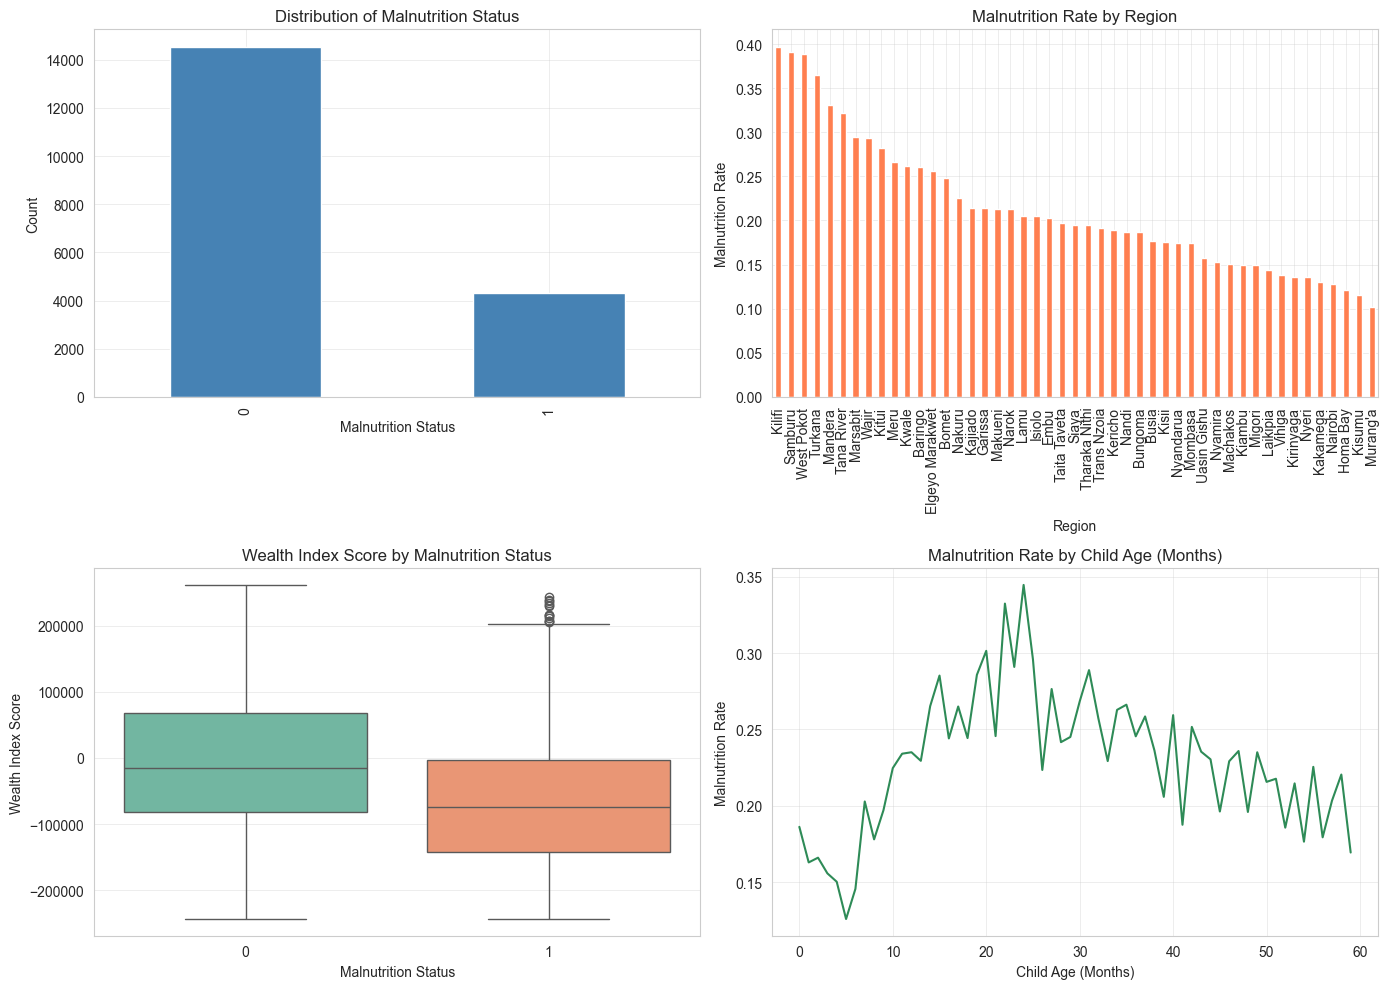

In [78]:
# Visualizations
fig, axes = plt.subplots(2, 2, figsize = (14, 10))

df[TARGET].value_counts().plot(kind = 'bar', ax = axes[0,0], color = 'steelblue')
axes[0,0].set_title('Distribution of Malnutrition Status')
axes[0,0].set_xlabel('Malnutrition Status')
axes[0,0].set_ylabel('Count')

df.groupby('region')[TARGET].mean().sort_values(ascending=False).plot(kind='bar', ax=axes[0,1], color='coral')
axes[0,1].set_title('Malnutrition Rate by Region')
axes[0,1].set_xlabel('Region')
axes[0,1].set_ylabel('Malnutrition Rate')
axes[0,1].tick_params(axis='x', rotation=90)

sns.boxplot(x=TARGET, y='wealth_index_score', data=df, ax=axes[1,0], palette='Set2')
axes[1,0].set_title('Wealth Index Score by Malnutrition Status')
axes[1,0].set_xlabel('Malnutrition Status')
axes[1,0].set_ylabel('Wealth Index Score')

df.groupby('child_age_months')[TARGET].mean().plot(kind='line', ax=axes[1,1], color='seagreen')
axes[1,1].set_title('Malnutrition Rate by Child Age (Months)')
axes[1,1].set_xlabel('Child Age (Months)')
axes[1,1].set_ylabel('Malnutrition Rate')

plt.tight_layout()
plt.savefig('../plots/eda_plots.png', dpi=300)
plt.show()

In [79]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

In [80]:
df.nunique()

cluster_id                            1691
household_id                           149
birth_order                             15
child_sex                                2
child_age_months                        60
mother_age_years                        35
region                                  47
residence_urban_rural                    2
mother_education_level                   4
mother_education_single_years           23
mother_working_status                    2
wealth_index_quintile                    5
wealth_index_score                   13390
children_ever_born                      15
age_at_first_birth                      32
mother_weight_kg                       725
mother_height_cm                       370
mother_bmi_x100                       2029
child_recent_diarrhea                    3
child_fever_recent                       3
drank_from_bottle_recently               2
fed_tinned_powdered_fresh_milk           3
has_malnutrition                         2
source_of_d

In [81]:
df_clean = df.drop(columns = ['cluster_id', 'household_id'])

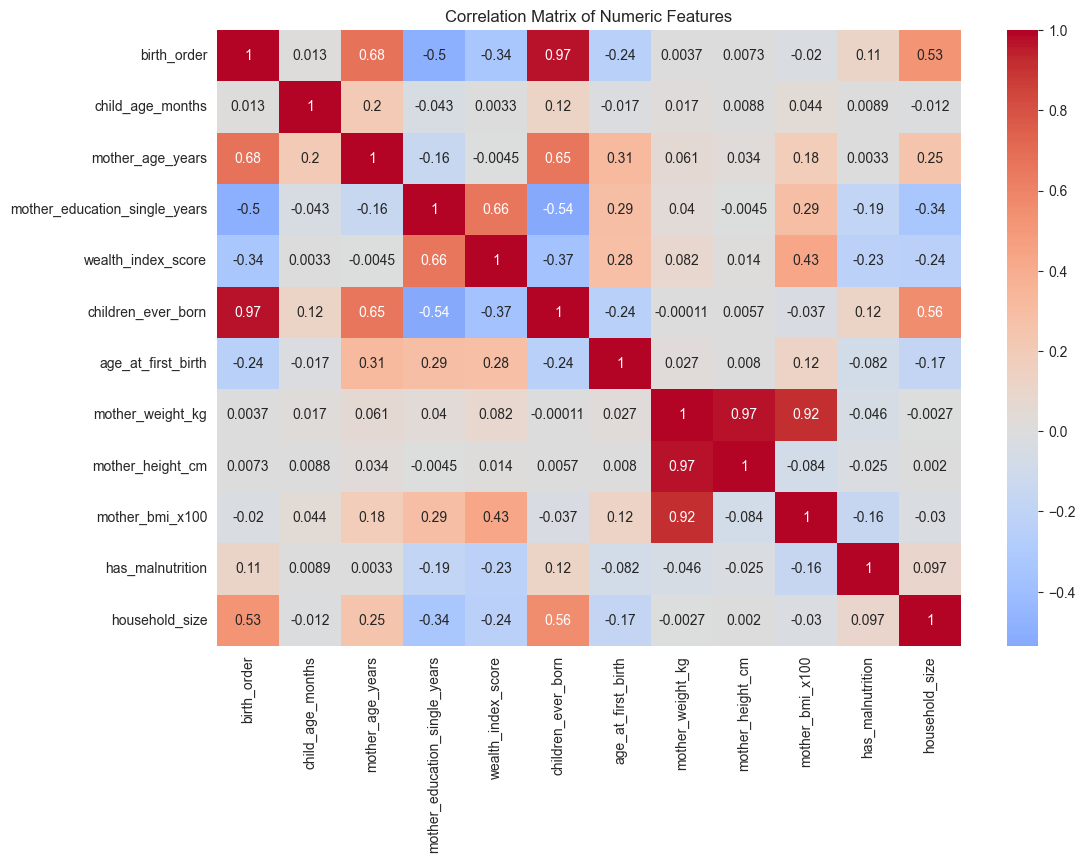

In [82]:
numeric_cols = df_clean.select_dtypes(include=np.number).columns
plt.figure(figsize=(12, 8))
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, cmap='coolwarm', center = 0)
plt.title('Correlation Matrix of Numeric Features')
plt.show()

In [83]:
df_clean = df_clean.drop(columns = ['children_ever_born', 'birth_order', 'mother_height_cm'])

In [84]:
df_clean.nunique()

child_sex                                2
child_age_months                        60
mother_age_years                        35
region                                  47
residence_urban_rural                    2
mother_education_level                   4
mother_education_single_years           23
mother_working_status                    2
wealth_index_quintile                    5
wealth_index_score                   13390
age_at_first_birth                      32
mother_weight_kg                       725
mother_bmi_x100                       2029
child_recent_diarrhea                    3
child_fever_recent                       3
drank_from_bottle_recently               2
fed_tinned_powdered_fresh_milk           3
has_malnutrition                         2
source_of_drinking_water                15
type_of_toilet_facility                 13
type_of_cooking_fuel                    11
household_size                          22
has_electricity                          2
has_refrige

In [85]:
exp_df = pd.DataFrame({
    'unique_values': df_clean.nunique(),
    'dtype': df_clean.dtypes
})
exp_df

,unique_values,dtype
child_sex,2,str
child_age_months,60,int64
mother_age_years,35,int64
region,47,object
residence_urban_rural,2,str
mother_education_level,4,str
mother_education_single_years,23,int64
mother_working_status,2,str
wealth_index_quintile,5,str
wealth_index_score,13390,int64


In [86]:
TARGET = 'has_malnutrition'
num_cols = df_clean.select_dtypes(include=np.number).columns.drop(TARGET).tolist()
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
print(f"Numeric columns: {num_cols}")
print(f"Categorical columns: {cat_cols}")

Numeric columns: ['child_age_months', 'mother_age_years', 'mother_education_single_years', 'wealth_index_score', 'age_at_first_birth', 'mother_weight_kg', 'mother_bmi_x100', 'household_size']
Categorical columns: ['child_sex', 'region', 'residence_urban_rural', 'mother_education_level', 'mother_working_status', 'wealth_index_quintile', 'child_recent_diarrhea', 'child_fever_recent', 'drank_from_bottle_recently', 'fed_tinned_powdered_fresh_milk', 'source_of_drinking_water', 'type_of_toilet_facility', 'type_of_cooking_fuel', 'has_electricity', 'has_refrigerator', 'main_floor_material', 'main_wall_material', 'main_roof_material', 'owns_farm_animals_livestock', 'has_land_suitable_for_agriculture']


In [87]:
feature_cols = num_cols + cat_cols
X = df_clean[feature_cols]
y = df_clean[TARGET]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Features: {len(feature_cols)} ({len(num_cols)} numeric, {len(cat_cols)} categorical)")

X shape: (18836, 28)
y shape: (18836,)
Features: 28 (8 numeric, 20 categorical)


In [88]:
df_clean[cat_cols].nunique().sort_values(ascending = False)

region                               47
main_wall_material                   17
source_of_drinking_water             15
main_roof_material                   15
type_of_toilet_facility              13
type_of_cooking_fuel                 11
main_floor_material                   9
wealth_index_quintile                 5
mother_education_level                4
fed_tinned_powdered_fresh_milk        3
child_fever_recent                    3
child_recent_diarrhea                 3
residence_urban_rural                 2
child_sex                             2
drank_from_bottle_recently            2
mother_working_status                 2
has_refrigerator                      2
has_electricity                       2
owns_farm_animals_livestock           2
has_land_suitable_for_agriculture     2
dtype: int64

In [89]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nClass distribution in training: {y_train.value_counts().to_dict()}")
print(f"Class distribution in test: {y_test.value_counts().to_dict()}")

Training set: (15068, 28)
Test set: (3768, 28)

Class distribution in training: {0: 11624, 1: 3444}
Class distribution in test: {0: 2907, 1: 861}


In [90]:
high_card_cols = [col for col in cat_cols if df_clean[col].nunique() > 10]
low_card_cols = [col for col in cat_cols if df_clean[col].nunique() <= 10]

print(f"High cardinality cols: {high_card_cols}")
print(f"Low cardinality cols: {low_card_cols}")
print(f"Numeric cols: {num_cols}")

High cardinality cols: ['region', 'source_of_drinking_water', 'type_of_toilet_facility', 'type_of_cooking_fuel', 'main_wall_material', 'main_roof_material']
Low cardinality cols: ['child_sex', 'residence_urban_rural', 'mother_education_level', 'mother_working_status', 'wealth_index_quintile', 'child_recent_diarrhea', 'child_fever_recent', 'drank_from_bottle_recently', 'fed_tinned_powdered_fresh_milk', 'has_electricity', 'has_refrigerator', 'main_floor_material', 'owns_farm_animals_livestock', 'has_land_suitable_for_agriculture']
Numeric cols: ['child_age_months', 'mother_age_years', 'mother_education_single_years', 'wealth_index_score', 'age_at_first_birth', 'mother_weight_kg', 'mother_bmi_x100', 'household_size']


In [91]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer, TargetEncoder
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
high_card_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', TargetEncoder())
])
low_card_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('high_card', high_card_pipeline, high_card_cols),
    ('low_card', low_card_pipeline, low_card_cols)
])

print("Preprocessing pipeline created successfully.")
print(f"Total features to process: {len(num_cols) + len(high_card_cols) + len(low_card_cols)}")

Preprocessing pipeline created successfully.
Total features to process: 28


In [92]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    GridSearchCV,
)
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    make_scorer,
)
import joblib

models = {
    "Logistic Regression": LogisticRegression(
        max_iter = 1000,
        random_state = 42,
        class_weight = 'balanced'
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=10,
        random_state = 42,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators = 100,
        max_depth = 10,
        random_state = 42,
        n_jobs = -1,
        class_weight = 'balanced'
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators = 100,
        max_depth = 5,
        random_state = 42
    ),
    "AdaBoost": AdaBoostClassifier(
        n_estimators = 100,
        random_state = 42
    ),
    "XGBoost": XGBClassifier(
        n_estimators = 100,
        max_depth= 5,
        random_state= 42,
        verbosity  = 0,
        eval_metrics = "logloss",
        use_label_encoder = False,
        scale_pos_weight=3.4
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors=5,
        n_jobs = -1
    ),
    "Naive Bayes": GaussianNB(),
}

print(f"Total models to evaluate: {len(models)}")
print(list(models.keys()))

Total models to evaluate: 8
['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'AdaBoost', 'XGBoost', 'KNN', 'Naive Bayes']


In [93]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": make_scorer(accuracy_score),
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "roc_auc": "roc_auc",
}

def get_pipeline(model):
    return ImbPipeline(
        [
            ("preprocessor", preprocessor),
            ("smote", SMOTE(random_state=42)),
            ("model", model),
        ]
    )
def get_positive_scores(fitted_pipeline, X):
    model = fitted_pipeline.named_steps["model"]

    if hasattr(model, "predict_proba"):
        return fitted_pipeline.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        return fitted_pipeline.decision_function(X)
    return None
def evaluate_test_set(fitted_pipeline, X_test, y_test):
    y_pred = fitted_pipeline.predict(X_test)
    y_score = get_positive_scores(fitted_pipeline, X_test)

    metrics = {
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Test Precision": precision_score(y_test, y_pred, zero_division=0),
        "Test Recall": recall_score(y_test, y_pred, zero_division=0),
        "Test F1": f1_score(y_test, y_pred, zero_division=0),
        "Test ROC-AUC": roc_auc_score(y_test, y_score)
        if y_score is not None
        else np.nan,
    }
    return y_pred, y_score, metrics

In [94]:
import time
cv_results = {}
trained_pipelines = {}
test_predictions = {}
test_scores = {}

for model_name, model in models.items():
    print(f"Cross-validating {model_name}...", end = " ")
    pipe = get_pipeline(model)
    start_time = time.time()

    cv_scores = cross_validate(
        estimator=pipe,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
    )

    cv_time = time.time() - start_time

    cv_results[model_name] = {
        "CV Accuracy Mean": cv_scores["test_accuracy"].mean(),
        "CV Accuracy Std": cv_scores["test_accuracy"].std(),
        "CV Precision Mean": cv_scores["test_precision"].mean(),
        "CV Recall Mean": cv_scores["test_recall"].mean(),
        "CV F1 Mean": cv_scores["test_f1"].mean(),
        "CV F1 Std": cv_scores["test_f1"].std(),
        "CV ROC-AUC Mean": cv_scores["test_roc_auc"].mean(),
        "CV ROC-AUC Std": cv_scores["test_roc_auc"].std(),
        "CV Time (s)": round(cv_time, 4),
    }

    fit_start = time.time()
    pipe.fit(X_train, y_train)
    fit_time = time.time() - fit_start

    y_pred, y_score, test_metrics = evaluate_test_set(
        pipe, X_test, y_test
    )

    cv_results[model_name].update(test_metrics)
    cv_results[model_name]["Fit Time Full Train (s)"] = round(fit_time, 4)

    trained_pipelines[model_name] = pipe
    test_predictions[model_name] = y_pred
    test_scores[model_name] = y_score

    print(
        f"✅ (CV F1 mean: {cv_results[model_name]['CV F1 Mean']:.4f}, "
        f"Test F1: {cv_results[model_name]['Test F1']:.4f})"
    )

print("\n✅ All models cross-validated, fitted, and evaluated successfully!")

Cross-validating Logistic Regression... ✅ (CV F1 mean: 0.4318, Test F1: 0.4431)
Cross-validating Decision Tree... ✅ (CV F1 mean: 0.3914, Test F1: 0.3814)
Cross-validating Random Forest... ✅ (CV F1 mean: 0.4298, Test F1: 0.4407)
Cross-validating Gradient Boosting... ✅ (CV F1 mean: 0.4079, Test F1: 0.4073)
Cross-validating AdaBoost... ✅ (CV F1 mean: 0.4063, Test F1: 0.4233)
Cross-validating XGBoost... ✅ (CV F1 mean: 0.3957, Test F1: 0.3854)
Cross-validating KNN... ✅ (CV F1 mean: 0.3769, Test F1: 0.3763)
Cross-validating Naive Bayes... ✅ (CV F1 mean: 0.3993, Test F1: 0.4014)

✅ All models cross-validated, fitted, and evaluated successfully!


In [95]:
results_df = pd.DataFrame(cv_results).T.sort_values(
    "CV F1 Mean", ascending=False
)

print("\n" + "=" * 100)
print("MODEL RANKING BY CROSS-VALIDATED F1")
print("=" * 100)
print(results_df.round(4))
print("=" * 100)

best_model_name = results_df.index[0]
best_pipeline = trained_pipelines[best_model_name]

print(f"\n🏆 Best model from CV: {best_model_name}")
print(
    f"CV F1 Mean: {results_df.loc[best_model_name, 'CV F1 Mean']:.4f} "
    f"+/- {results_df.loc[best_model_name, 'CV F1 Std']:.4f}"
)
print(f"Test F1: {results_df.loc[best_model_name, 'Test F1']:.4f}")


MODEL RANKING BY CROSS-VALIDATED F1
                     CV Accuracy Mean  CV Accuracy Std  CV Precision Mean  \
Logistic Regression            0.6218           0.0068             0.3289   
Random Forest                  0.6548           0.0260             0.3473   
Gradient Boosting              0.3963           0.0244             0.2630   
AdaBoost                       0.3946           0.0775             0.2636   
Naive Bayes                    0.3709           0.0295             0.2556   
XGBoost                        0.3367           0.0217             0.2499   
Decision Tree                  0.5969           0.0570             0.3038   
KNN                            0.5757           0.0068             0.2837   

                     CV Recall Mean  CV F1 Mean  CV F1 Std  CV ROC-AUC Mean  \
Logistic Regression          0.6289      0.4318     0.0082           0.6714   
Random Forest                0.5694      0.4298     0.0061           0.6804   
Gradient Boosting            0.9

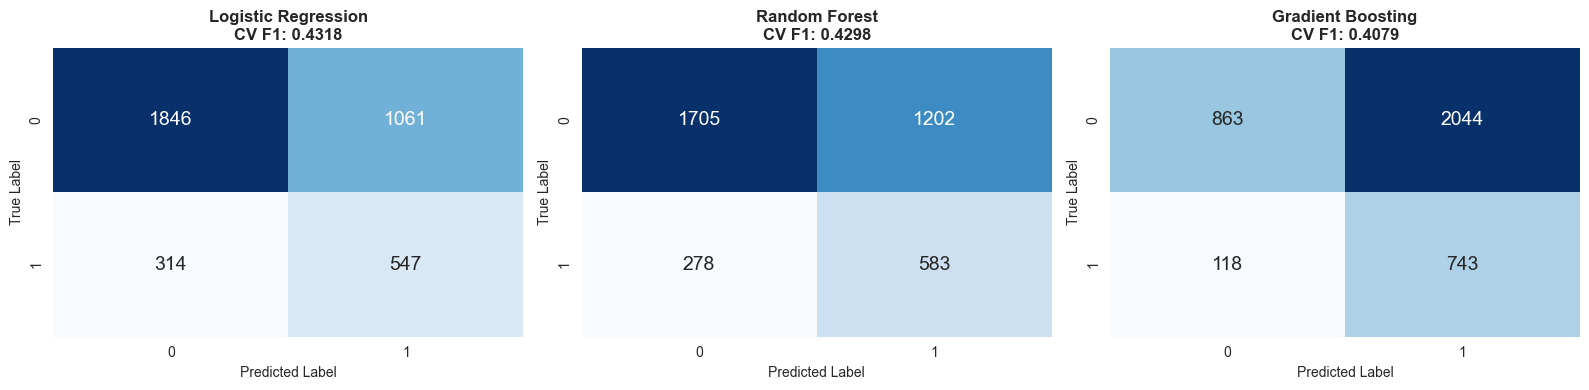

✅ Confusion matrices for top 3 CV-ranked models displayed


In [96]:
#confusion matrix for of top 3 models
# REPLACEMENT FOR:
# confusion matrix top 3 models cell

top_3_models = results_df.head(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for idx, model_name in enumerate(top_3_models):
    y_pred = test_predictions[model_name]
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[idx],
        cbar=False,
        annot_kws={"size": 14},
    )

    axes[idx].set_title(
        f"{model_name}\nCV F1: {results_df.loc[model_name, 'CV F1 Mean']:.4f}",
        fontweight="bold",
    )
    axes[idx].set_ylabel("True Label")
    axes[idx].set_xlabel("Predicted Label")

plt.tight_layout()
plt.show()

print("✅ Confusion matrices for top 3 CV-ranked models displayed")

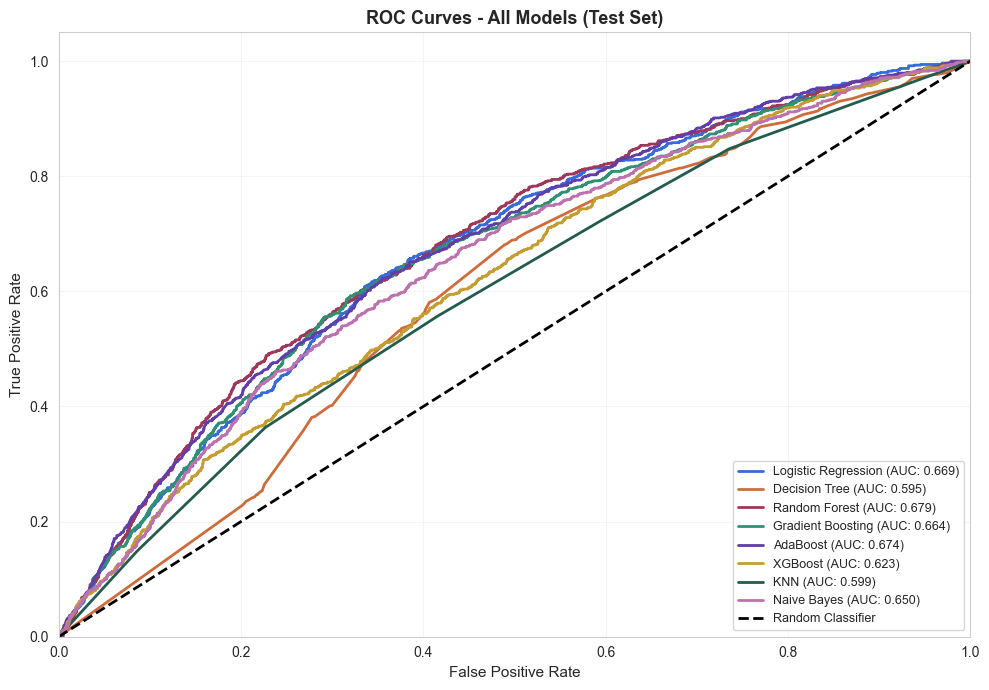

✅ ROC curves displayed


In [97]:
# ROC Curves for all models
# REPLACEMENT FOR:
# ROC curves for all models cell

plt.figure(figsize=(10, 7))

for model_name, pipe in trained_pipelines.items():
    y_score = test_scores[model_name]

    if y_score is not None:
        fpr, tpr, _ = roc_curve(y_test, y_score)
        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            lw=2,
            label=f"{model_name} (AUC: {roc_auc:.3f})",
        )

plt.plot([0, 1], [0, 1], "k--", lw=2, label="Random Classifier")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate", fontsize=11)
plt.ylabel("True Positive Rate", fontsize=11)
plt.title("ROC Curves - All Models (Test Set)", fontsize=13, fontweight="bold")
plt.legend(loc="lower right", fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ ROC curves displayed")

In [98]:
# REPLACEMENT FOR:
# detailed classification report for best model cell

best_model_name = results_df.index[0]
best_pipeline = trained_pipelines[best_model_name]
best_y_pred = test_predictions[best_model_name]

print("\n" + "=" * 60)
print(f"BEST MODEL FROM CV: {best_model_name}")
print("=" * 60)
print("\nClassification Report (Test Set):")
print(
    classification_report(
        y_test,
        best_y_pred,
        target_names=["not malnourished", "Malnourished"],
        zero_division=0,
    )
)


BEST MODEL FROM CV: Logistic Regression

Classification Report (Test Set):
                  precision    recall  f1-score   support

not malnourished       0.85      0.64      0.73      2907
    Malnourished       0.34      0.64      0.44       861

        accuracy                           0.64      3768
       macro avg       0.60      0.64      0.59      3768
    weighted avg       0.74      0.64      0.66      3768



In [99]:
# feature importance cell

best_estimator = best_pipeline.named_steps["model"]

if hasattr(best_estimator, "feature_importances_"):
    fitted_preprocessor = best_pipeline.named_steps["preprocessor"]
    feature_names = fitted_preprocessor.get_feature_names_out()

    importance_df = pd.DataFrame(
        {
            "Feature": feature_names,
            "Importance": best_estimator.feature_importances_,
        }
    ).sort_values("Importance", ascending=False).head(15)

    plt.figure(figsize=(10, 6))
    plt.barh(
        importance_df["Feature"][::-1],
        importance_df["Importance"][::-1],
        color="steelblue",
    )
    plt.xlabel("Importance", fontsize=11)
    plt.title(
        f"Top 15 Feature Importances - {best_model_name}",
        fontsize=13,
        fontweight="bold",
    )
    plt.tight_layout()
    plt.show()

    print("\nTop Feature Importances:")
    print(importance_df)
else:
    print(
        f"Note: {best_model_name} does not provide built-in feature importance scores."
    )

Note: Logistic Regression does not provide built-in feature importance scores.


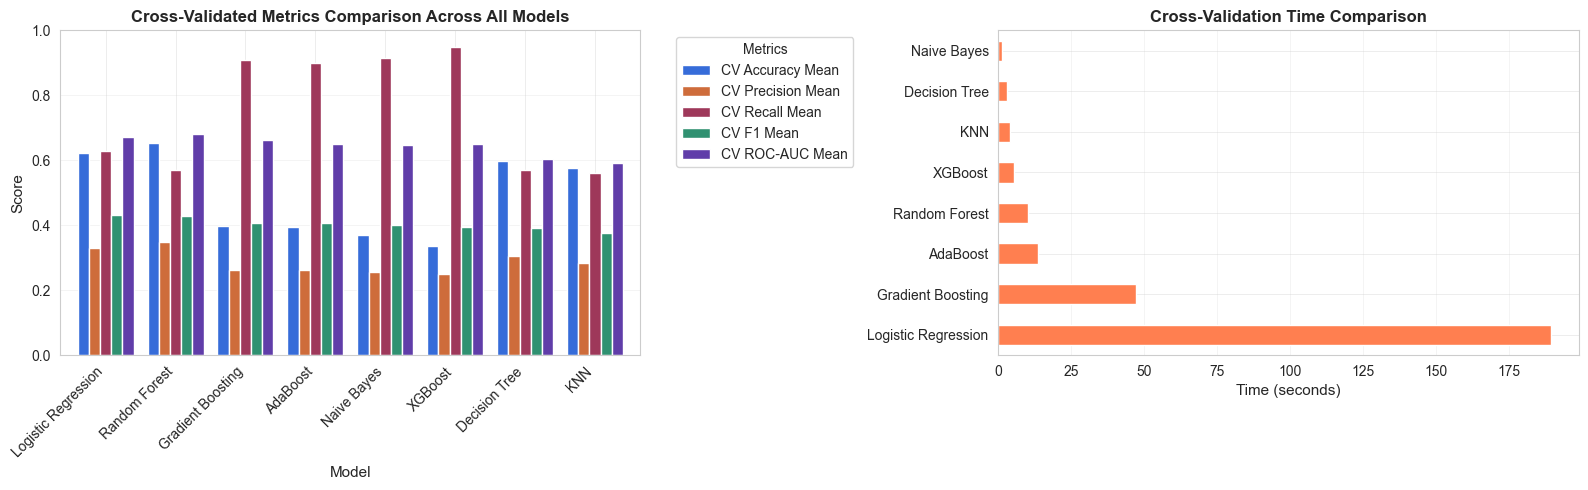

✅ CV model comparison visualizations displayed


In [100]:
# model comparison visualization cell

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

cv_metrics_to_plot = [
    "CV Accuracy Mean",
    "CV Precision Mean",
    "CV Recall Mean",
    "CV F1 Mean",
    "CV ROC-AUC Mean",
]

results_df[cv_metrics_to_plot].plot(kind="bar", ax=axes[0], width=0.8)
axes[0].set_title(
    "Cross-Validated Metrics Comparison Across All Models",
    fontsize=12,
    fontweight="bold",
)
axes[0].set_ylabel("Score", fontsize=11)
axes[0].set_xlabel("Model", fontsize=11)
axes[0].legend(title="Metrics", bbox_to_anchor=(1.05, 1), loc="upper left")
axes[0].set_ylim([0, 1])
axes[0].grid(axis="y", alpha=0.3)
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha="right")

cv_times = results_df["CV Time (s)"].sort_values(ascending=False)
cv_times.plot(kind="barh", ax=axes[1], color="coral")
axes[1].set_title(
    "Cross-Validation Time Comparison",
    fontsize=12,
    fontweight="bold",
)
axes[1].set_xlabel("Time (seconds)", fontsize=11)
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ CV model comparison visualizations displayed")